<a href="https://colab.research.google.com/github/siddhidamkondwar/Practical_Machine_Learning/blob/main/ML_03_06_26_day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from numpy import linalg
import scipy
from scipy import stats
from scipy.stats import binom
from scipy.stats import poisson
from scipy.stats import norm, t
from scipy.stats import expon
from collections import Counter
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import statsmodels.stats
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson
from statsmodels.stats.rates import test_poisson_2indep
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split

impoet dataset

In [ ]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name='faithful')

split for train test

In [ ]:
scipy.stats.pearsonr(df.eruptions,df.waiting)

PearsonRResult(statistic=np.float64(0.9008111683218132), pvalue=np.float64(8.129958506615525e-100))

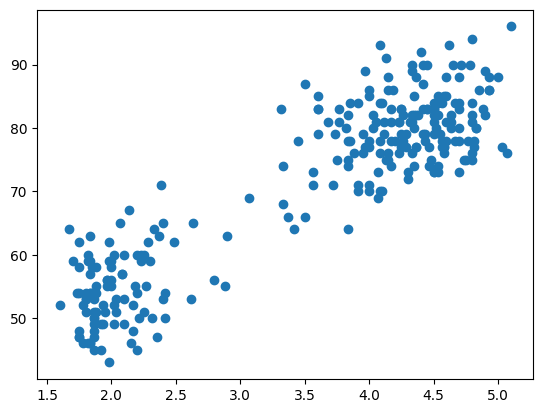

In [ ]:
plt.scatter(df.eruptions,df.waiting)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(df.waiting,df.eruptions, test_size=0.3, random_state=20)

In [ ]:
x_train.head()

,waiting
182,83
248,67
50,75
209,83
200,60


In [ ]:
y_train.head()

,eruptions
182,4.250
248,2.133
50,4.800
209,4.500
200,2.100


In [ ]:
df.shape

(272, 2)

In [ ]:
x_train.shape

(190,)

Add constant term

In [ ]:
x_train = sm.add_constant(x_train, prepend=False)

In [ ]:
x_test = sm.add_constant(x_test, prepend=False)


In [ ]:
x_train.head()

,waiting,const
182,83,1.0
248,67,1.0
50,75,1.0
209,83,1.0
200,60,1.0


# Prepare the model

In [ ]:
mod1 = sm.OLS(y_train,x_train).fit()

In [ ]:
print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:              eruptions   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                     771.1
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           1.94e-68
Time:                        11:47:01   Log-Likelihood:                -140.85
No. Observations:                 190   AIC:                             285.7
Df Residuals:                     188   BIC:                             292.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
waiting        0.0782      0.003     27.768      0.0

In [ ]:
# M = 0.0782
# C = -2.0814
# p-value =  P>|t|
0.0782/0.003

26.066666666666666

In [ ]:
-2.0814/0.203

-10.25320197044335

In [ ]:
mydata = pd.DataFrame([[80,1],[90,1],[100,1]],columns= x_train.columns)

In [ ]:
mypreds = mod1.predict(mydata)

In [ ]:
mypreds

,0
0,4.176827
1,4.959109
2,5.741392


In [ ]:
y_preds = mod1.predict(x_train)

In [ ]:
y_preds.head(

)

,0
182,4.411512
248,3.159859
50,3.785686
209,4.411512
200,2.612262


In [ ]:
y_train.head()

,eruptions
182,4.250
248,2.133
50,4.800
209,4.500
200,2.100


In [ ]:
residuals = y_train - y_preds

In [ ]:
sum(residuals)

5.684341886080801e-13

(array([ 5.,  9., 18., 30., 25., 36., 30., 20., 13.,  4.]),
 array([-1.25817472, -1.01204863, -0.76592254, -0.51979646, -0.27367037,
        -0.02754428,  0.21858181,  0.4647079 ,  0.71083398,  0.95696007,
         1.20308616]),
 <BarContainer object of 10 artists>)

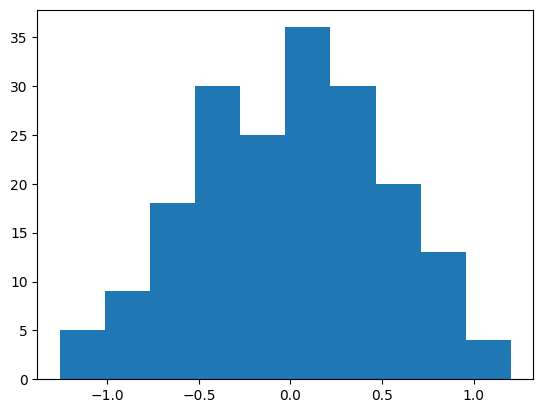

In [ ]:
plt.hist(residuals)

In [ ]:
SSE = sum(residuals**2)

In [ ]:
SSE       #sum square of Error

48.99679457123917

In [ ]:
SST =  sum((y_train - np.mean(y_train))**2)
# SST stands for Sum Square of Total variation

In [ ]:
SST

249.95112065263157

In [ ]:
SSR  =  SST - SSE

In [ ]:
# sum square of regression or explained variation

In [ ]:
SSR/SST        #this ratio is the same as R2

# fraction of total variation explaine dby the model

0.803974495320098

In [ ]:
F = ((SSR)/(1)) / (SSE/(188))

In [ ]:
#No of values = 190
# total DOF = 189
#DOF for regression model = 2-1 =1
# Dof for error or residy\ual = 189 - 1 = 188

In [ ]:
F

771.0588750529828

In [ ]:
from scipy.stats import f

In [ ]:
p_value = 1 - f.cdf(F,1,188)

In [ ]:
p_value

np.float64(1.1102230246251565e-16)

# *SKLEARN*

In [ ]:
from sklearn.linear_model import LinearRegression

Creating an instance for the funnction

In [ ]:
regr1 = LinearRegression()

splitting

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(df.waiting,df.eruptions, test_size=0.3, random_state=20)

reshaping

In [ ]:
x_train = np.array(x_test).reshape(-1,1)

In [ ]:
y_train = np.array(y_test).reshape(-1,1)

create the model

In [ ]:
mod_sk = regr1.fit(x_train,y_train)

values ofr the coefficient

In [ ]:
regr1.coef_

array([[0.07050583]])

values for the intercept

In [ ]:
regr1.intercept_

array([-1.45400112])

R2 (based on the training set)

In [ ]:
regr1.score(x_train,y_train)

0.8381100909531985

making prediction

In [ ]:
y_preds = regr1.predict(x_train)

In [ ]:
from sklearn.metrics import mean_squared_error

Calculate the mean squared error between y_pred and y_train

In [ ]:
mse1 =  mean_squared_error(y_preds,y_train)

In [ ]:
mse1

0.20172066850483414

In [ ]:
SSE

48.99679457123917

In [ ]:
SSE/190

0.2578778661644167

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
cross_val_score(regr1,x_train,y_train,scoring='neg_mean_squared_error',cv=5)        #validation

array([-0.17526432, -0.35829677, -0.08823569, -0.11497342, -0.31470598])

In [ ]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name='stackloss')

In [ ]:
df.head()

,AirFlow,WaterTemp,AcidConc,StackLoss
0,80,27,89,42
1,80,27,88,37
2,75,25,90,37
3,62,24,87,28
4,62,22,87,18


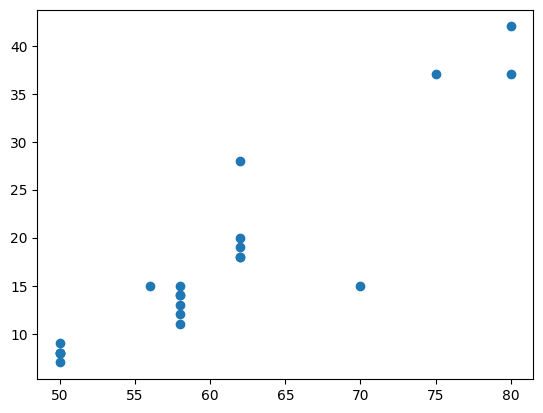

In [ ]:
plt.scatter(df.AirFlow,df.StackLoss)

In [ ]:
#CC = 0.2 between A and B
# there is no relation between A and B

In [ ]:
 #Split for train-test
x_train, x_test, y_train, y_test = train_test_split(df.drop('StackLoss', axis=1),df.StackLoss, test_size=0.1, random_state=20)

# Add constant term
x_train = sm.add_constant(x_train, prepend=False)
x_test = sm.add_constant(x_test, prepend=False)

# Prepare the model
mod1 = sm.OLS(y_train,x_train).fit()

print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:              StackLoss   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     46.11
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           1.67e-07
Time:                        12:16:15   Log-Likelihood:                -45.877
No. Observations:                  18   AIC:                             99.75
Df Residuals:                      14   BIC:                             103.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
AirFlow        0.7001      0.152      4.592      0.0